In [1]:
import os
import pandas as pd
from io import StringIO
from dotenv import load_dotenv
from gsheet_loader import load_sheet

load_dotenv()

# Load a Google Sheet URL from .env
url = os.getenv("GOOGLE_SHEET_URL")
if not url:
    raise ValueError("GOOGLE_SHEET_URL is not set in .env")

data = load_sheet(url)

In [2]:
fixed_text = data.getvalue().encode("latin1").decode("utf-8")
df = pd.read_csv(StringIO(fixed_text))

In [3]:
df.head()

,age,gender,profession,location,wornSilk,frequency,types,occasions,purchaseSource,budget,purchasePreference,qualityOpinion,priceVsQuality,productIssue,knowGI,seenVideo,promoUseful,buyOnline
0,18–25,Male,Student,Rajshahi,No,Never,Never Used,Never Used,Never bought,1000–3000 BDT,Quality,Average,No,Yes,Yes,Yes,Extremely helpful,Yes
1,18–25,Male,Student,Rajshahi,No,Never,Never Used,Never Used,Rajshahi Silk Emporium,1000–3000 BDT,Price,Good,Yes,No,No,Yes,Helpful,No
2,18–25,Male,Student,Rajshahi,No,Never,Never Used,Never Used,Never bought,Above 5000 BDT,Other,Don't know,Not sure,No,No,Yes,Helpful,Yes
3,18–25,Female,Student,Rajshahi,Yes,Rarely,Kameez,Casual use,Boutique or brand shop,1000–3000 BDT,Quality,Good,Not sure,No,Yes,No,Neutral,No
4,18–25,Female,Student,Rajshahi,No,Never,Never Used,Never Used,Never bought,Less than 1000 BDT,Price,Average,No,No,No,Yes,Neutral,No


## 4.1 Data Preparation

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import chi2_contingency

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

# Brand-neutral, colorblind-safe categorical palette
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2",
           "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD"]
sns.set_palette(PALETTE)

print("Raw shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("\nMissing values per column:\n", df.isnull().sum())

Raw shape: (134, 18)
Duplicate rows: 1

Missing values per column:
 age                   0
gender                0
profession            0
location              0
wornSilk              0
frequency             0
types                 0
occasions             0
purchaseSource        0
budget                0
purchasePreference    0
qualityOpinion        0
priceVsQuality        0
productIssue          0
knowGI                0
seenVideo             0
promoUseful           0
buyOnline             0
dtype: int64


In [5]:
# --- Data screening & cleaning ---

# 1. Remove exact duplicate responses
df_clean = df.drop_duplicates().reset_index(drop=True)
n_removed = df.shape[0] - df_clean.shape[0]
print(f"Removed {n_removed} duplicate response(s). New shape: {df_clean.shape}")

# 2. Strip whitespace from all string cells
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].str.strip()

# 3. Ordered categories for variables with a natural order (used for tables/charts/tests)
age_order = ["18–25", "26–35", "36–50", "Above 50"]
frequency_order = ["Never", "Rarely", "Sometimes", "Regularly"]
budget_order = ["Less than 1000 BDT", "1000–3000 BDT", "3000–5000 BDT", "Above 5000 BDT"]
quality_order = ["Poor", "Average", "Good", "Excellent", "Don't know"]
promo_order = ["Not helpful at all", "Not helpful", "Neutral", "Helpful", "Extremely helpful"]

df_clean["age"] = pd.Categorical(df_clean["age"], categories=age_order, ordered=True)
df_clean["frequency"] = pd.Categorical(df_clean["frequency"], categories=frequency_order, ordered=True)
df_clean["budget"] = pd.Categorical(df_clean["budget"], categories=budget_order, ordered=True)
df_clean["qualityOpinion"] = pd.Categorical(df_clean["qualityOpinion"], categories=quality_order, ordered=True)
df_clean["promoUseful"] = pd.Categorical(df_clean["promoUseful"], categories=promo_order, ordered=True)

print(f"\nFinal cleaned dataset: {df_clean.shape[0]} respondents, {df_clean.shape[1]} variables")
df_clean.head()

Removed 1 duplicate response(s). New shape: (133, 18)

Final cleaned dataset: 133 respondents, 18 variables


C:\Users\zibsh\AppData\Local\Temp\ipykernel_20916\451274823.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include="object").columns:


,age,gender,profession,location,wornSilk,frequency,types,occasions,purchaseSource,budget,purchasePreference,qualityOpinion,priceVsQuality,productIssue,knowGI,seenVideo,promoUseful,buyOnline
0,18–25,Male,Student,Rajshahi,No,Never,Never Used,Never Used,Never bought,1000–3000 BDT,Quality,Average,No,Yes,Yes,Yes,Extremely helpful,Yes
1,18–25,Male,Student,Rajshahi,No,Never,Never Used,Never Used,Rajshahi Silk Emporium,1000–3000 BDT,Price,Good,Yes,No,No,Yes,Helpful,No
2,18–25,Male,Student,Rajshahi,No,Never,Never Used,Never Used,Never bought,Above 5000 BDT,Other,Don't know,Not sure,No,No,Yes,Helpful,Yes
3,18–25,Female,Student,Rajshahi,Yes,Rarely,Kameez,Casual use,Boutique or brand shop,1000–3000 BDT,Quality,Good,Not sure,No,Yes,No,Neutral,No
4,18–25,Female,Student,Rajshahi,No,Never,Never Used,Never Used,Never bought,Less than 1000 BDT,Price,Average,No,No,No,Yes,Neutral,No


In [6]:
# --- Reusable helpers for frequency tables & charts ---

def freq_table(series, order=None):
    """Return a frequency + percentage table for a categorical variable."""
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).dropna()
    table = pd.DataFrame({
        "Frequency (n)": counts.astype(int),
        "Percentage (%)": (counts / counts.sum() * 100).round(1)
    })
    table.index.name = None
    return table


def bar_chart(series, title, order=None, horizontal=False, figsize=(6, 4)):
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).dropna()
    fig, ax = plt.subplots(figsize=figsize)
    if horizontal:
        sns.barplot(x=counts.values, y=counts.index.astype(str), ax=ax, color=PALETTE[0])
        ax.set_xlabel("Number of Respondents")
        ax.set_ylabel("")
        for i, v in enumerate(counts.values):
            ax.text(v + max(counts.values) * 0.01, i, str(v), va="center")
    else:
        sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax, color=PALETTE[0])
        ax.set_ylabel("Number of Respondents")
        ax.set_xlabel("")
        for i, v in enumerate(counts.values):
            ax.text(i, v + max(counts.values) * 0.01, str(v), ha="center")
        plt.xticks(rotation=30, ha="right")
    ax.set_title(title, fontsize=12, fontweight="bold")
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()


def pie_chart(series, title, order=None, figsize=(5, 5)):
    counts = series.value_counts(dropna=False)
    if order is not None:
        counts = counts.reindex(order).dropna()
    fig, ax = plt.subplots(figsize=figsize)
    ax.pie(
        counts.values, labels=counts.index.astype(str),
        autopct="%1.1f%%", startangle=90, colors=PALETTE,
        wedgeprops={"edgecolor": "white", "linewidth": 1}
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.axis("equal")
    plt.tight_layout()
    plt.show()


def stacked_bar(df_in, group_col, stack_col, title, group_order=None, stack_order=None, figsize=(7, 4.5)):
    ct = pd.crosstab(df_in[group_col], df_in[stack_col], normalize="index") * 100
    if group_order is not None:
        ct = ct.reindex([g for g in group_order if g in ct.index])
    if stack_order is not None:
        ct = ct[[c for c in stack_order if c in ct.columns]]
    ax = ct.plot(kind="bar", stacked=True, figsize=figsize, color=PALETTE[:ct.shape[1]])
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(title=stack_col, bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    plt.xticks(rotation=0)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

## 4.2 Descriptive Analysis

### 4.2.1 Demographic Characteristics

Table 4.1: Age Distribution


,Frequency (n),Percentage (%)
18–25,115,86.5
26–35,14,10.5
36–50,2,1.5
Above 50,2,1.5


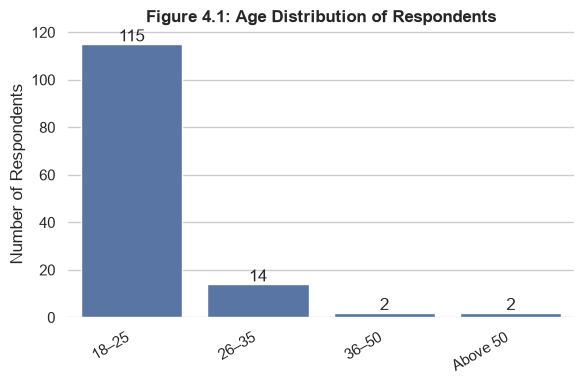

In [7]:
# Table 4.1 Age Distribution
print("Table 4.1: Age Distribution")
display(freq_table(df_clean["age"], order=age_order))
bar_chart(df_clean["age"], "Figure 4.1: Age Distribution of Respondents", order=age_order)

Table 4.2: Gender Distribution


,Frequency (n),Percentage (%)
Female,72,54.1
Male,61,45.9


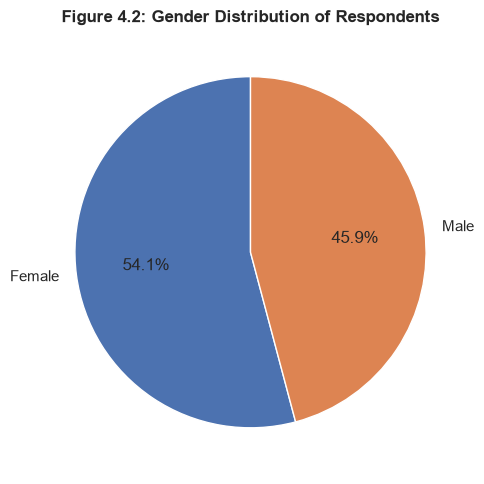

In [8]:
# Table 4.2 Gender Distribution
print("Table 4.2: Gender Distribution")
display(freq_table(df_clean["gender"]))
pie_chart(df_clean["gender"], "Figure 4.2: Gender Distribution of Respondents")

Table 4.3: Profession Distribution


,Frequency (n),Percentage (%)
Student,119,89.5
Housewife,4,3.0
Service Holder,4,3.0
Other,4,3.0
Businessperson,2,1.5


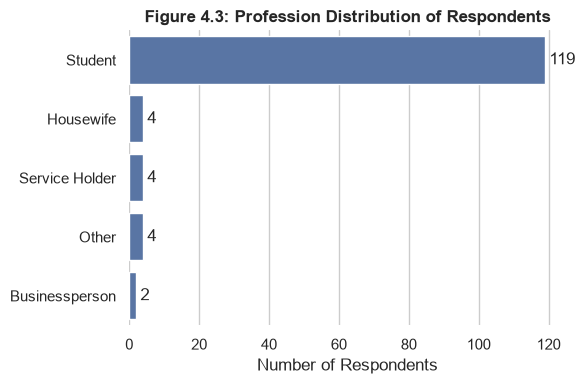

In [9]:
# Table 4.3 Profession Distribution
print("Table 4.3: Profession Distribution")
display(freq_table(df_clean["profession"]))
bar_chart(df_clean["profession"], "Figure 4.3: Profession Distribution of Respondents", horizontal=True)

Table 4.4: Location Distribution (grouped)


,Frequency (n),Percentage (%)
Rajshahi,104,78.2
Dhaka,12,9.0
Other district,17,12.8



Table 4.4b: Location Distribution (all districts reported)


,Frequency (n),Percentage (%)
Rajshahi,104,78.2
Dhaka,12,9.0
Mymensingh,2,1.5
Natore,2,1.5
Jhalokathi,1,0.8
Bhola,1,0.8
Faridpur,1,0.8
Narayanganj,1,0.8
Sylhet,1,0.8
Other,1,0.8


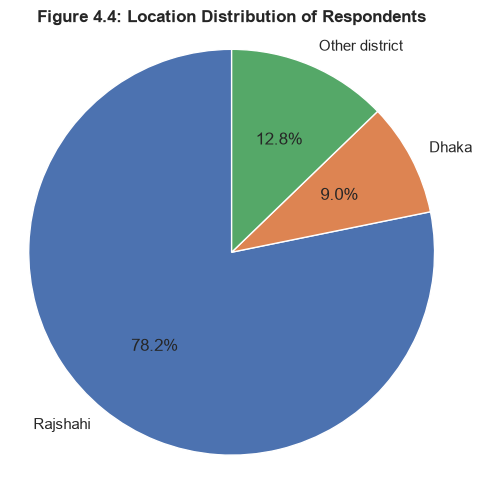

In [10]:
# Table 4.4 Location Distribution
# Raw location has many sparse categories (17 towns) -> collapse into a readable grouping
# for the table/chart, while keeping the original column for reference.
def group_location(loc):
    if loc == "Rajshahi":
        return "Rajshahi"
    elif loc == "Dhaka":
        return "Dhaka"
    else:
        return "Other district"

df_clean["locationGrouped"] = df_clean["location"].apply(group_location)

print("Table 4.4: Location Distribution (grouped)")
display(freq_table(df_clean["locationGrouped"], order=["Rajshahi", "Dhaka", "Other district"]))

print("\nTable 4.4b: Location Distribution (all districts reported)")
display(freq_table(df_clean["location"]))

pie_chart(df_clean["locationGrouped"], "Figure 4.4: Location Distribution of Respondents",
          order=["Rajshahi", "Dhaka", "Other district"])

### 4.2.2 Consumer Experience with Rajshahi Silk

Table 4.5: Respondents Who Have Worn Rajshahi Silk


,Frequency (n),Percentage (%)
Yes,72,54.1
No,61,45.9


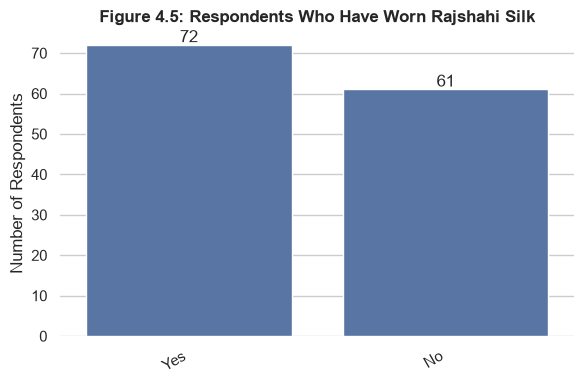

In [11]:
# Respondents who have worn Rajshahi silk
print("Table 4.5: Respondents Who Have Worn Rajshahi Silk")
display(freq_table(df_clean["wornSilk"]))
bar_chart(df_clean["wornSilk"], "Figure 4.5: Respondents Who Have Worn Rajshahi Silk")

Table 4.6: Buying Frequency


,Frequency (n),Percentage (%)
Never,49,36.8
Rarely,36,27.1
Sometimes,45,33.8
Regularly,3,2.3


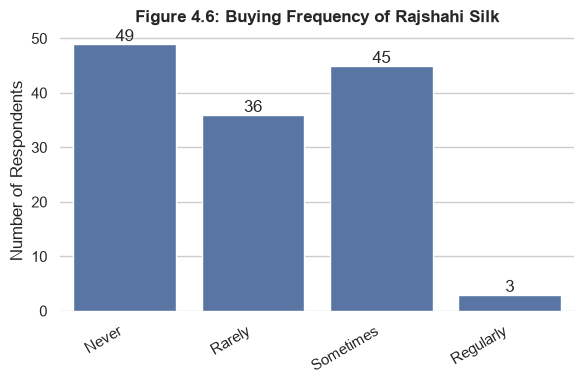

In [12]:
# Buying frequency
print("Table 4.6: Buying Frequency")
display(freq_table(df_clean["frequency"], order=frequency_order))
bar_chart(df_clean["frequency"], "Figure 4.6: Buying Frequency of Rajshahi Silk", order=frequency_order)

Table 4.7: Preferred Silk Products


,Frequency (n),Percentage (%)
Never Used,47,35.3
Saree,46,34.6
Panjabi,18,13.5
Three-piece,7,5.3
Kameez,6,4.5
Shirt,4,3.0
Scarf,3,2.3
Other,2,1.5


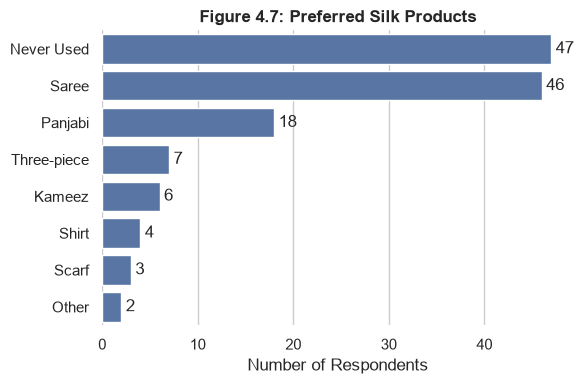

In [13]:
# Preferred silk products (types)
print("Table 4.7: Preferred Silk Products")
display(freq_table(df_clean["types"]))
bar_chart(df_clean["types"], "Figure 4.7: Preferred Silk Products", horizontal=True)

Table 4.8: Occasions for Wearing Silk


,Frequency (n),Percentage (%)
Never Used,47,35.3
Special event,29,21.8
Festival,25,18.8
Other,12,9.0
Casual use,10,7.5
Wedding,7,5.3
Daily,2,1.5
Party,1,0.8


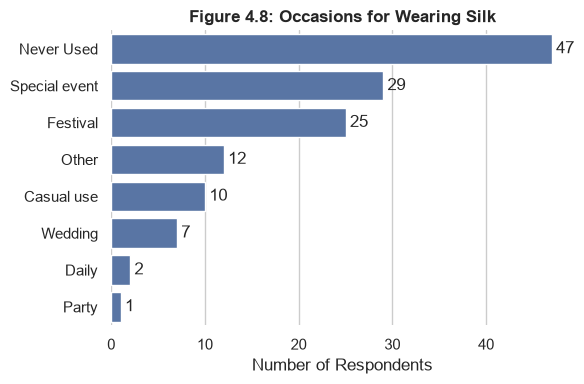

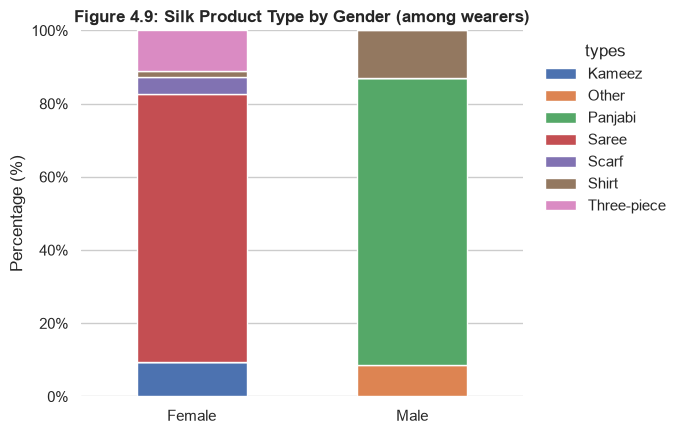

In [14]:
# Occasions for wearing silk
print("Table 4.8: Occasions for Wearing Silk")
display(freq_table(df_clean["occasions"]))
bar_chart(df_clean["occasions"], "Figure 4.8: Occasions for Wearing Silk", horizontal=True)

# Stacked bar: gender x silk types worn (excluding "Never Used" for clarity of preference pattern)
worn_only = df_clean[df_clean["types"] != "Never Used"]
stacked_bar(worn_only, "gender", "types", "Figure 4.9: Silk Product Type by Gender (among wearers)")

### 4.2.3 Purchasing Behavior

Table 4.9: Preferred Purchasing Source


,Frequency (n),Percentage (%)
Rajshahi Silk Emporium,54,40.6
Never bought,40,30.1
Local market,16,12.0
Online store,12,9.0
Boutique or brand shop,11,8.3


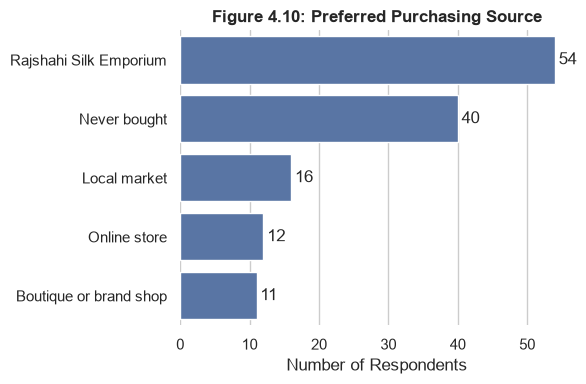

In [15]:
# Preferred purchasing source
print("Table 4.9: Preferred Purchasing Source")
display(freq_table(df_clean["purchaseSource"]))
bar_chart(df_clean["purchaseSource"], "Figure 4.10: Preferred Purchasing Source", horizontal=True)

Table 4.10: Budget Distribution


,Frequency (n),Percentage (%)
Less than 1000 BDT,26,19.5
1000–3000 BDT,73,54.9
3000–5000 BDT,24,18.0
Above 5000 BDT,10,7.5


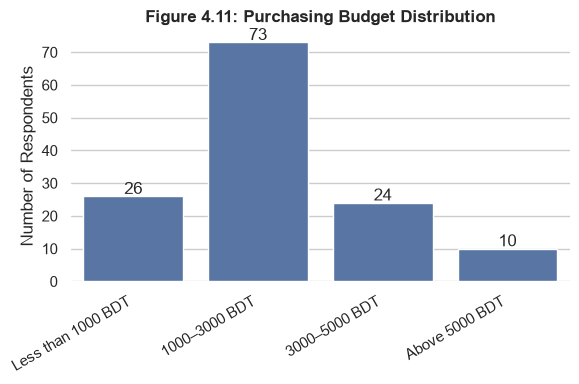

In [16]:
# Budget distribution
print("Table 4.10: Budget Distribution")
display(freq_table(df_clean["budget"], order=budget_order))
bar_chart(df_clean["budget"], "Figure 4.11: Purchasing Budget Distribution", order=budget_order)

Table 4.11: Purchase Preference


,Frequency (n),Percentage (%)
Quality,104,78.2
Price,16,12.0
Other,5,3.8
Color,5,3.8
Durability,3,2.3


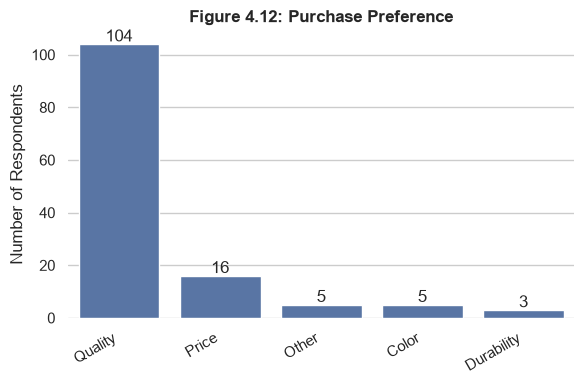

In [17]:
# Purchase preference
print("Table 4.11: Purchase Preference")
display(freq_table(df_clean["purchasePreference"]))
bar_chart(df_clean["purchasePreference"], "Figure 4.12: Purchase Preference")

Table 4.12: Online Buying Intention


,Frequency (n),Percentage (%)
Yes,71,53.4
No,62,46.6


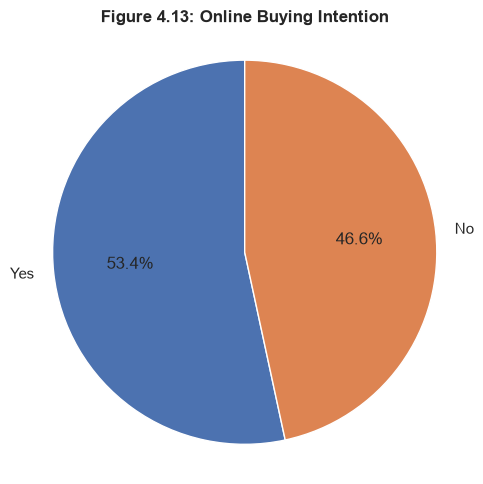

In [18]:
# Online buying intention
print("Table 4.12: Online Buying Intention")
display(freq_table(df_clean["buyOnline"]))
pie_chart(df_clean["buyOnline"], "Figure 4.13: Online Buying Intention")

### 4.2.4 Consumer Perception

Table 4.13: Consumer Opinion Regarding Product Quality


,Frequency (n),Percentage (%)
Poor,3,2.3
Average,16,12.0
Good,47,35.3
Excellent,46,34.6
Don't know,21,15.8


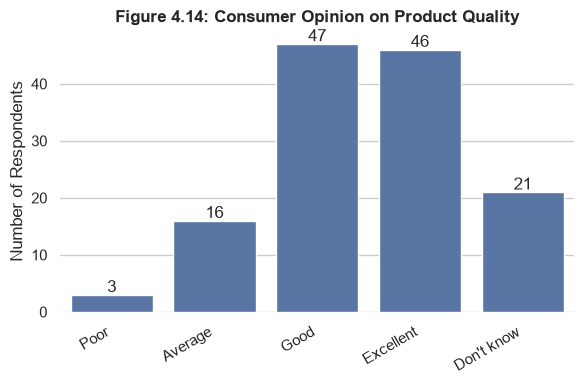

In [19]:
# Consumer opinion regarding product quality
print("Table 4.13: Consumer Opinion Regarding Product Quality")
display(freq_table(df_clean["qualityOpinion"], order=quality_order))
bar_chart(df_clean["qualityOpinion"], "Figure 4.14: Consumer Opinion on Product Quality", order=quality_order)

Table 4.14: Price-Quality Perception ("Is the price justified by the quality?")


,Frequency (n),Percentage (%)
Not sure,51,38.3
Yes,49,36.8
No,33,24.8


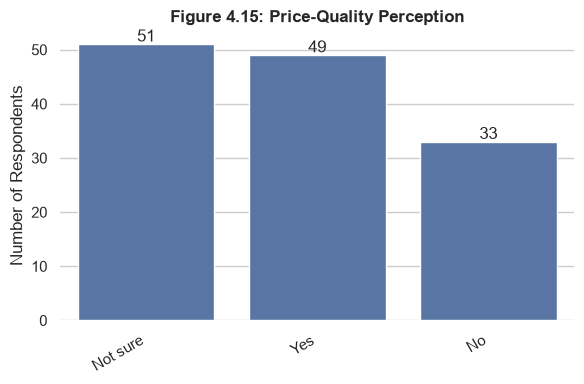

In [20]:
# Price vs quality perception
print("Table 4.14: Price-Quality Perception (\"Is the price justified by the quality?\")")
display(freq_table(df_clean["priceVsQuality"]))
bar_chart(df_clean["priceVsQuality"], "Figure 4.15: Price-Quality Perception")

Table 4.15: Problems Experienced While Purchasing Silk


,Frequency (n),Percentage (%)
No,116,87.2
Yes,17,12.8


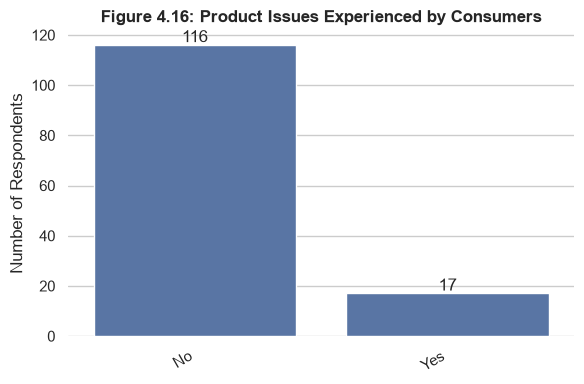

In [21]:
# Problems experienced while purchasing silk
print("Table 4.15: Problems Experienced While Purchasing Silk")
display(freq_table(df_clean["productIssue"]))
bar_chart(df_clean["productIssue"], "Figure 4.16: Product Issues Experienced by Consumers")

### 4.2.5 Awareness and Marketing

Table 4.16: GI Awareness


,Frequency (n),Percentage (%)
Yes,85,63.9
No,48,36.1


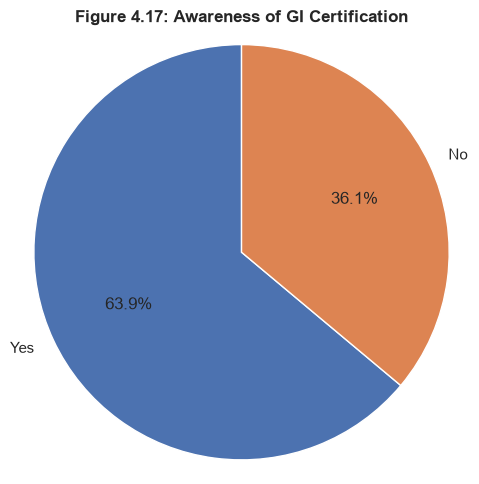

In [22]:
# GI (Geographical Indication) awareness
print("Table 4.16: GI Awareness")
display(freq_table(df_clean["knowGI"]))
pie_chart(df_clean["knowGI"], "Figure 4.17: Awareness of GI Certification")

Table 4.17: Promotional Exposure


,Frequency (n),Percentage (%)
Yes,93,69.9
No,40,30.1


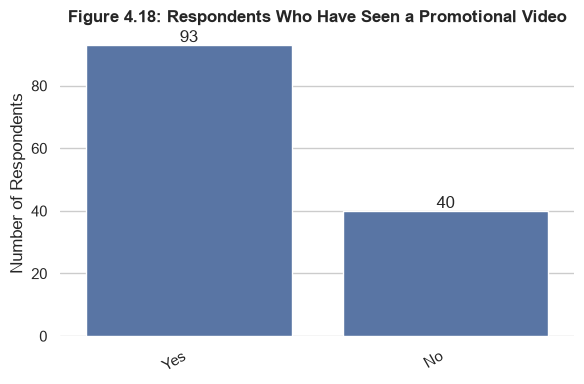

In [23]:
# Promotional exposure (seen video)
print("Table 4.17: Promotional Exposure")
display(freq_table(df_clean["seenVideo"]))
bar_chart(df_clean["seenVideo"], "Figure 4.18: Respondents Who Have Seen a Promotional Video")

Table 4.18: Marketing Effectiveness (Promotional Video Usefulness)


,Frequency (n),Percentage (%)
Not helpful at all,7,5.3
Not helpful,6,4.5
Neutral,32,24.1
Helpful,64,48.1
Extremely helpful,24,18.0


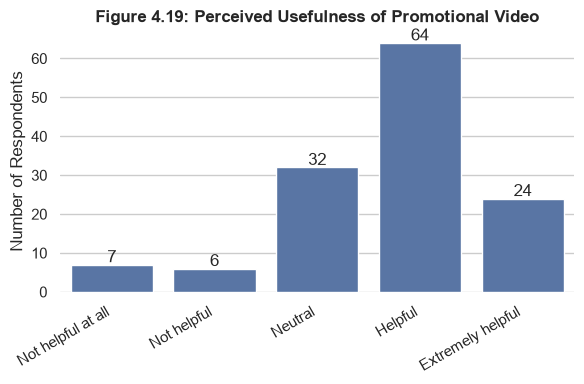

In [24]:
# Marketing effectiveness (promotional video usefulness)
print("Table 4.18: Marketing Effectiveness (Promotional Video Usefulness)")
display(freq_table(df_clean["promoUseful"], order=promo_order))
bar_chart(df_clean["promoUseful"], "Figure 4.19: Perceived Usefulness of Promotional Video", order=promo_order)

## 4.3 Inferential Analysis — Chi-square Test of Independence

## 4.4 Association Strength (Cramer's V)

For every hypothesis below we report the Chi-square statistic (χ²), degrees of freedom (df),
p-value, and Cramer's V as the effect-size measure of association strength.

| Cramer's V | Interpretation |
|---|---|
| 0.10–0.19 | Weak |
| 0.20–0.39 | Moderate |
| ≥ 0.40 | Strong |

In [25]:
def cramers_v(chi2_stat, n, r, c):
    """Cramer's V effect size for a chi-square test of independence."""
    return np.sqrt((chi2_stat / n) / (min(r - 1, c - 1)))


def interpret_v(v):
    if v >= 0.40:
        return "Strong"
    elif v >= 0.20:
        return "Moderate"
    elif v >= 0.10:
        return "Weak"
    else:
        return "Negligible"


hypothesis_results = []  # collects rows for the 4.5 summary table


def run_chi_square(hypothesis_id, hypothesis_text, var1, var2, alpha=0.05, var1_order=None, var2_order=None):
    """Run a Chi-square test of independence between var1 and var2, print the
    contingency table, test statistics, Cramer's V, and decision; store the
    result row for the summary table."""
    ct = pd.crosstab(df_clean[var1], df_clean[var2])
    if var1_order is not None:
        ct = ct.reindex([v for v in var1_order if v in ct.index])
    if var2_order is not None:
        ct = ct[[v for v in var2_order if v in ct.columns]]

    chi2_stat, p_value, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    v = cramers_v(chi2_stat, n, ct.shape[0], ct.shape[1])
    decision = "Rejected (significant association)" if p_value < alpha else "Accepted (no significant association)"

    print(f"{hypothesis_id}: {hypothesis_text}")
    print(f"Variables: {var1} x {var2}")
    print("\nContingency table (counts):")
    display(ct)

    min_expected = expected.min()
    pct_low_expected = (expected < 5).mean() * 100
    print(f"\nChi-square = {chi2_stat:.3f}, df = {dof}, p-value = {p_value:.4f}")
    print(f"Cramer's V = {v:.3f} ({interpret_v(v)} association)")
    if pct_low_expected > 20:
        print(f"Note: {pct_low_expected:.0f}% of cells have expected count < 5 "
              f"(min expected = {min_expected:.2f}) — interpret with caution (small-sample limitation).")
    print(f"Decision (alpha = {alpha}): H0 {'REJECTED' if p_value < alpha else 'NOT REJECTED'} -> {decision}")
    print("-" * 90)

    hypothesis_results.append({
        "Hypothesis": hypothesis_id,
        "Variables": f"{var1} x {var2}",
        "Chi-square": round(chi2_stat, 3),
        "df": dof,
        "p-value": round(p_value, 4),
        "Cramer's V": round(v, 3),
        "Strength": interpret_v(v),
        "Decision": decision,
    })
    return chi2_stat, p_value, dof, v

### H1 — Gender is associated with silk usage

In [26]:
run_chi_square("H1", "Gender is associated with silk usage", "gender", "wornSilk")

H1: Gender is associated with silk usage
Variables: gender x wornSilk

Contingency table (counts):


wornSilk,No,Yes
gender,,
Female,17,55
Male,44,17



Chi-square = 29.387, df = 1, p-value = 0.0000
Cramer's V = 0.470 (Strong association)
Decision (alpha = 0.05): H0 REJECTED -> Rejected (significant association)
------------------------------------------------------------------------------------------


(np.float64(29.387101467915663),
 np.float64(5.927082751868184e-08),
 1,
 np.float64(0.47005919854280503))

### H2 — Age influences buying frequency

In [27]:
run_chi_square("H2", "Age influences buying frequency", "age", "frequency",
               var1_order=age_order, var2_order=frequency_order)

H2: Age influences buying frequency
Variables: age x frequency

Contingency table (counts):


frequency,Never,Rarely,Sometimes,Regularly
age,,,,
18–25,43,29,40,3
26–35,4,5,5,0
36–50,1,1,0,0
Above 50,1,1,0,0



Chi-square = 3.635, df = 9, p-value = 0.9338
Cramer's V = 0.095 (Negligible association)
Note: 75% of cells have expected count < 5 (min expected = 0.05) — interpret with caution (small-sample limitation).
Decision (alpha = 0.05): H0 NOT REJECTED -> Accepted (no significant association)
------------------------------------------------------------------------------------------


(np.float64(3.6347357783693193),
 np.float64(0.9337693943100969),
 9,
 np.float64(0.09544429516541234))

### H3 — Profession influences purchasing budget

In [28]:
run_chi_square("H3", "Profession influences purchasing budget", "profession", "budget",
               var2_order=budget_order)

H3: Profession influences purchasing budget
Variables: profession x budget

Contingency table (counts):


budget,Less than 1000 BDT,1000–3000 BDT,3000–5000 BDT,Above 5000 BDT
profession,,,,
Businessperson,0,2,0,0
Housewife,0,2,2,0
Other,1,3,0,0
Service Holder,1,2,1,0
Student,24,64,21,10



Chi-square = 7.056, df = 12, p-value = 0.8539
Cramer's V = 0.133 (Weak association)
Note: 80% of cells have expected count < 5 (min expected = 0.15) — interpret with caution (small-sample limitation).
Decision (alpha = 0.05): H0 NOT REJECTED -> Accepted (no significant association)
------------------------------------------------------------------------------------------


(np.float64(7.055895395566023),
 np.float64(0.853897732219844),
 12,
 np.float64(0.132981007515414))

### H4 — Location influences purchasing source

In [29]:
# Note: the raw `location` variable has 17 sparse categories (many with n=1), which would
# violate Chi-square's expected-frequency assumptions. We use the grouped variable
# (Rajshahi / Dhaka / Other district) created in section 4.2.1 for a valid test.
run_chi_square("H4", "Location influences purchasing source", "locationGrouped", "purchaseSource",
               var1_order=["Rajshahi", "Dhaka", "Other district"])

H4: Location influences purchasing source
Variables: locationGrouped x purchaseSource

Contingency table (counts):


purchaseSource,Boutique or brand shop,Local market,Never bought,Online store,Rajshahi Silk Emporium
locationGrouped,,,,,
Rajshahi,6,14,31,6,47
Dhaka,1,0,3,2,6
Other district,4,2,6,4,1



Chi-square = 19.264, df = 8, p-value = 0.0135
Cramer's V = 0.269 (Moderate association)
Note: 53% of cells have expected count < 5 (min expected = 0.99) — interpret with caution (small-sample limitation).
Decision (alpha = 0.05): H0 REJECTED -> Rejected (significant association)
------------------------------------------------------------------------------------------


(np.float64(19.263927786538083),
 np.float64(0.013510133360242413),
 8,
 np.float64(0.2691110944431664))

### H5 — GI awareness is associated with online purchase intention

In [30]:
run_chi_square("H5", "GI awareness is associated with online purchase intention", "knowGI", "buyOnline")

H5: GI awareness is associated with online purchase intention
Variables: knowGI x buyOnline

Contingency table (counts):


buyOnline,No,Yes
knowGI,,
No,21,27
Yes,41,44



Chi-square = 0.101, df = 1, p-value = 0.7512
Cramer's V = 0.027 (Negligible association)
Decision (alpha = 0.05): H0 NOT REJECTED -> Accepted (no significant association)
------------------------------------------------------------------------------------------


(np.float64(0.1005063011688093),
 np.float64(0.7512228967993733),
 1,
 np.float64(0.027489752180648218))

### H6 — Watching promotional videos influences purchase intention

In [31]:
run_chi_square("H6", "Watching promotional videos influences purchase intention", "seenVideo", "buyOnline")

H6: Watching promotional videos influences purchase intention
Variables: seenVideo x buyOnline

Contingency table (counts):


buyOnline,No,Yes
seenVideo,,
No,24,16
Yes,38,55



Chi-square = 3.384, df = 1, p-value = 0.0658
Cramer's V = 0.160 (Weak association)
Decision (alpha = 0.05): H0 NOT REJECTED -> Accepted (no significant association)
------------------------------------------------------------------------------------------


(np.float64(3.384162089690413),
 np.float64(0.06582562948167928),
 1,
 np.float64(0.1595143496430123))

### H7 — Product issues influence quality perception

In [32]:
run_chi_square("H7", "Product issues influence quality perception", "productIssue", "qualityOpinion",
               var2_order=quality_order)

H7: Product issues influence quality perception
Variables: productIssue x qualityOpinion

Contingency table (counts):


qualityOpinion,Poor,Average,Good,Excellent,Don't know
productIssue,,,,,
No,0,10,44,43,19
Yes,3,6,3,3,2



Chi-square = 32.783, df = 4, p-value = 0.0000
Cramer's V = 0.496 (Strong association)
Note: 40% of cells have expected count < 5 (min expected = 0.38) — interpret with caution (small-sample limitation).
Decision (alpha = 0.05): H0 REJECTED -> Rejected (significant association)
------------------------------------------------------------------------------------------


(np.float64(32.782824521719114),
 np.float64(1.3232288301644911e-06),
 4,
 np.float64(0.49647497662917583))

### H8 — Buying frequency differs according to purchase source

In [33]:
run_chi_square("H8", "Buying frequency differs according to purchase source", "frequency", "purchaseSource",
               var1_order=frequency_order)

H8: Buying frequency differs according to purchase source
Variables: frequency x purchaseSource

Contingency table (counts):


purchaseSource,Boutique or brand shop,Local market,Never bought,Online store,Rajshahi Silk Emporium
frequency,,,,,
Never,1,0,39,2,7
Rarely,4,11,1,1,19
Sometimes,6,4,0,8,27
Regularly,0,1,0,1,1



Chi-square = 107.814, df = 12, p-value = 0.0000
Cramer's V = 0.520 (Strong association)
Note: 60% of cells have expected count < 5 (min expected = 0.25) — interpret with caution (small-sample limitation).
Decision (alpha = 0.05): H0 REJECTED -> Rejected (significant association)
------------------------------------------------------------------------------------------


(np.float64(107.81395385735662),
 np.float64(1.6178805297554726e-17),
 12,
 np.float64(0.5198176706019783))

## 4.5 Summary of Hypothesis Testing

In [34]:
summary_table = pd.DataFrame(hypothesis_results).set_index("Hypothesis")
summary_table

,Variables,Chi-square,df,p-value,Cramer's V,Strength,Decision
Hypothesis,,,,,,,
H1,gender x wornSilk,29.387,1,0.0000,0.470,Strong,Rejected (significant association)
H2,age x frequency,3.635,9,0.9338,0.095,Negligible,Accepted (no significant association)
H3,profession x budget,7.056,12,0.8539,0.133,Weak,Accepted (no significant association)
H4,locationGrouped x purchaseSource,19.264,8,0.0135,0.269,Moderate,Rejected (significant association)
H5,knowGI x buyOnline,0.101,1,0.7512,0.027,Negligible,Accepted (no significant association)
H6,seenVideo x buyOnline,3.384,1,0.0658,0.160,Weak,Accepted (no significant association)
H7,productIssue x qualityOpinion,32.783,4,0.0000,0.496,Strong,Rejected (significant association)
H8,frequency x purchaseSource,107.814,12,0.0000,0.520,Strong,Rejected (significant association)


## 4.6 Discussion

*(To be written after reviewing the tables/figures and hypothesis results above. Cover:)*

- Key demographic characteristics of respondents (age, gender, profession, location — see 4.2.1).
- Consumer purchasing behavior toward Rajshahi silk (frequency, source, budget — see 4.2.2–4.2.3).
- Factors affecting consumer perception of quality and price (4.2.4).
- Awareness of GI certification and its relationship to online buying intention (H5).
- Effectiveness of promotional videos on purchase intention (H6).
- Significant associations identified by the Chi-square tests (H1–H8, see 4.5), with reference to Cramer's V effect sizes.
- Implications for marketers, manufacturers, and policymakers in the Rajshahi silk industry.

## 4.7 Conclusion

*(To be written. Summarize:)*

- Respondent profile.
- Consumer preferences for silk products and occasions of use.
- Purchasing behavior (source, budget, online intention).
- Perception of quality and price fairness.
- Marketing/GI awareness levels.
- Which hypotheses showed statistically significant relationships (and their strength).
- Recommendations for improving marketing, distribution, and GI-based branding of Rajshahi silk.

---

### Statistical Methods Used

| Objective | Method |
|---|---|
| Data cleaning | Screening, deduplication, and coding |
| Respondent profile | Frequency and Percentage |
| Consumer behavior | Frequency and Percentage |
| Consumer perception | Frequency and Percentage |
| Marketing awareness | Frequency and Percentage |
| Association between categorical variables | Chi-square Test of Independence |
| Strength of association | Cramer's V |
| Data visualization | Bar charts, Pie charts, Stacked bar charts |